# 01 - Exploratory Data Analysis (NER)
**NLP Deliverable 2 — Named Entity Recognition**

This notebook explores the training/test data (`train_data_ner.csv`, `test_data_ner.csv`)
used for the NER task. It produces the statistics reported in the EDA section of `main.pdf`.

> The notebook is **Colab-friendly**: it auto-installs the few extra packages and
> auto-detects the data location.

In [1]:
# === Setup (works locally and on Google Colab) ===
import sys, os
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # On Colab: upload train_data_ner.csv / test_data_ner.csv / tiny_test.csv
    # to the working dir, or mount Drive and point DATA_DIR there.
    DATA_DIR = '.'                  # e.g. '/content/drive/MyDrive/nlp_d2_data'
else:
    DATA_DIR = '../nlp_d2_data'     # local repo layout

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
print('Data dir:', DATA_DIR)

Data dir: ../nlp_d2_data


In [2]:
# Load the raw token-level tables (CSV has commas/quotes inside `words`,
# so we always rely on the pandas CSV parser, never manual splitting).
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_data_ner.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test_data_ner.csv'))
train_df['words'] = train_df['words'].astype(str)
test_df['words']  = test_df['words'].astype(str)
display(train_df.head())

,sentence_id,words,tags
0,0,Thousands,O
1,0,of,O
2,0,demonstrators,O
3,0,have,O
4,0,marched,O


## 1. Dataset size

In [3]:
def basic_stats(df, name):
    n_sent = df['sentence_id'].nunique()
    n_tok = len(df)
    print(f'{name:6s} | sentences: {n_sent:7d} | tokens: {n_tok:8d} | '
          f'avg tokens/sentence: {n_tok/n_sent:.2f}')

basic_stats(train_df, 'train')
basic_stats(test_df,  'test')

train  | sentences:   38366 | tokens:   839149 | avg tokens/sentence: 21.87
test   | sentences:   38367 | tokens:   837339 | avg tokens/sentence: 21.82


## 2. Sentence length distribution

mean     21.872205
std       7.989460
min       1.000000
max     104.000000
dtype: float64
95th percentile: 35


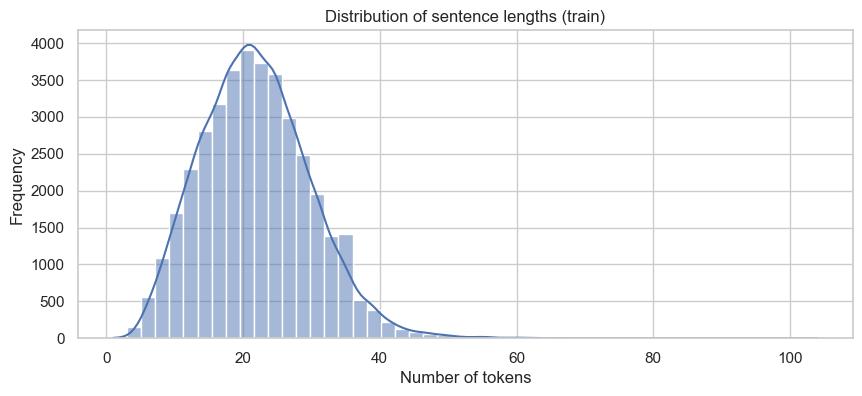

In [4]:
sent_len = train_df.groupby('sentence_id').size()
print(sent_len.describe()[['mean','std','min','max']])
print('95th percentile:', int(sent_len.quantile(0.95)))

plt.figure(figsize=(10,4))
sns.histplot(sent_len, bins=50, kde=True)
plt.title('Distribution of sentence lengths (train)')
plt.xlabel('Number of tokens'); plt.ylabel('Frequency')
plt.show()

## 3. Tag distribution (with and without `O`)

In [5]:
tag_counts = train_df['tags'].value_counts()
print('Full tag distribution:')
print(tag_counts)
print(f"\n'O' tokens represent {tag_counts['O']/len(train_df)*100:.1f}% of all tokens "
      f"-> strong class imbalance.")

Full tag distribution:
tags
O        710391
B-geo     30113
B-tim     16317
B-org     16127
I-per     13845
B-per     13568
I-org     13526
B-gpe     12739
I-geo      5898
I-tim      5258
B-art       314
B-eve       244
I-art       242
I-eve       205
I-gpe       161
B-nat       157
I-nat        44
Name: count, dtype: int64

'O' tokens represent 84.7% of all tokens -> strong class imbalance.


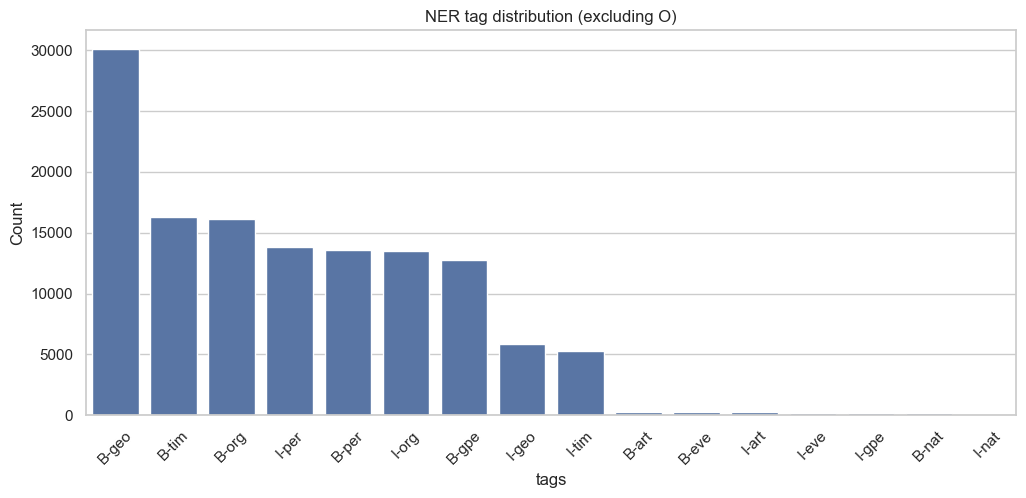

In [6]:
no_o = train_df[train_df['tags'] != 'O']
plt.figure(figsize=(12,5))
sns.countplot(data=no_o, x='tags', order=no_o['tags'].value_counts().index)
plt.title('NER tag distribution (excluding O)')
plt.xticks(rotation=45); plt.ylabel('Count')
plt.show()

## 4. Entity types and B-/I- split

Tokens per entity TYPE:
etype
geo    36011
org    29653
per    27413
tim    21575
gpe    12900
art      556
eve      449
nat      201
Name: count, dtype: int64

B- vs I- split:
prefix
B    89579
I    39179
Name: count, dtype: int64


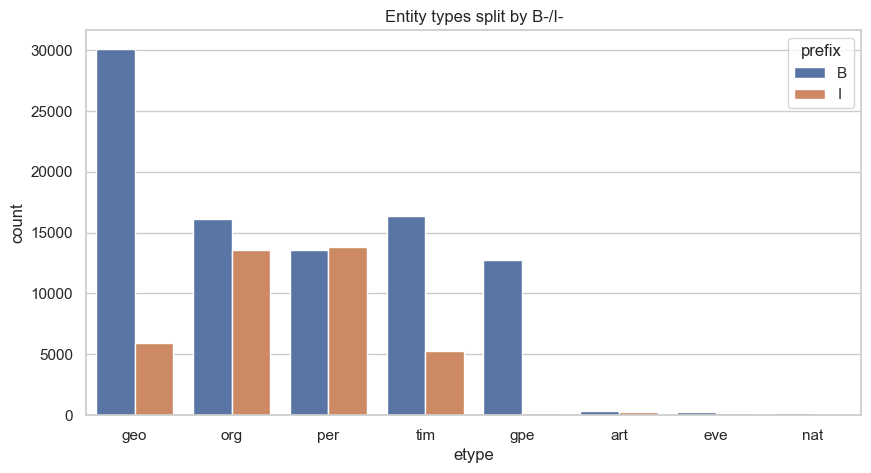

In [7]:
tmp = no_o.copy()
tmp['prefix'] = tmp['tags'].str[0]          # B or I
tmp['etype']  = tmp['tags'].str[2:]         # geo, org, per, ...
print('Tokens per entity TYPE:')
print(tmp['etype'].value_counts())
print('\nB- vs I- split:')
print(tmp['prefix'].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(data=tmp, x='etype', hue='prefix',
              order=tmp['etype'].value_counts().index)
plt.title('Entity types split by B-/I-')
plt.show()

## 5. Out-of-vocabulary (OOV) analysis
Fraction of test tokens whose surface form was never seen in training. This motivates
the `<UNK>` token used by the BiLSTM and the sub-word tokenization used by DistilBERT.

In [8]:
train_vocab = set(train_df['words'].str.lower())
test_words = test_df['words'].str.lower()
oov_rate = (~test_words.isin(train_vocab)).mean()
print(f'OOV rate on test set: {oov_rate*100:.2f}%')

OOV rate on test set: 11.62%


## 6. Most frequent surface forms per entity type

In [9]:
for et in ['geo','org','per','tim','gpe']:
    top = (no_o[no_o['tags'].str[2:] == et]['words']
           .value_counts().head(8).index.tolist())
    print(f'{et:4s}: {top}')

geo : ['U.S.', 'Iraq', 'Iran', 'United', 'States', 'Afghanistan', 'China', 'Israel']
org : ['U.S.', 'United', 'Nations', 'U.N.', 'Taleban', 'of', 'and', 'NATO']
per : ['Mr.', 'President', 'Bush', 'Prime', 'Minister', 'Chavez', 'Obama', 'Abbas']
tim : ['Tuesday', 'Thursday', 'Friday', 'Wednesday', 'Monday', 'Sunday', 'Saturday', 'of']
gpe : ['Iraqi', 'Israeli', 'Palestinian', 'Afghan', 'American', 'British', 'Russian', 'Chinese']


## 7. Takeaways
- The data is heavily dominated by the `O` tag (~83% of tokens), so we evaluate
  accuracy **only on tokens whose ground-truth tag is not `O`** (as required by the guide).
- `geo`, `org`, `per`, `tim`, `gpe` are well represented; `art`, `eve`, `nat` are rare
  (hundreds of tokens) and will be the hardest classes.
- A non-trivial OOV rate justifies generalization features (suffixes/word-shape in the CRF,
  `<UNK>` in the BiLSTM, sub-words in DistilBERT).